# 텐서플로우 모델 구축 방법 3가지

# 딥러닝 라이브러리 2가지
## 텐서플로우(google) - 산업용
* 이미지 관련 라이브러리
* keras를 이용해 코딩이 쉬움
* 순차적, 함수적, 클래스

## 파이토치(meta) - 연구용
* 자연어 관련 라이브러리
* 허깅페이스, 랭체인
* 클래스
* 학습의 모든 과정을 커스텀화 할 수 있음

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ablearn/main/Taitanic_train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [4]:
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']]
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S


In [6]:
data['family']=data['SibSp'] + data['Parch']
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,family
0,0,3,male,22.0,1,0,S,1
1,1,1,female,38.0,1,0,C,1
2,1,3,female,26.0,0,0,S,0
3,1,1,female,35.0,1,0,S,1
4,0,3,male,35.0,0,0,S,0


In [9]:
data = data.drop(['SibSp', 'Parch'], axis=1)
data.head()

,Survived,Pclass,Sex,Age,Embarked,family
0,0,3,male,22.0,S,1
1,1,1,female,38.0,C,1
2,1,3,female,26.0,S,0
3,1,1,female,35.0,S,1
4,0,3,male,35.0,S,0


In [10]:
X = data.drop('Survived', axis=1)
y = data['Survived']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, stratify=y, random_state=42)

In [13]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 623 entries, 748 to 136
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    623 non-null    int64  
 1   Sex       623 non-null    str    
 2   Age       504 non-null    float64
 3   Embarked  621 non-null    str    
 4   family    623 non-null    int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 29.2 KB


# 딥러닝시에도 데이터 스케일을 맞춰 주어야 함
* MinMaxScaler를 주로 사용, StandardScaler도 사용, 이상값이 많은 경우 RobustScaler 사용
* 이진분류: MinMaxScaler
* 연속값예측: StandardScaler

In [14]:
X_train.columns

Index(['Pclass', 'Sex', 'Age', 'Embarked', 'family'], dtype='str')

In [15]:
num_cols = ['Age', 'family']
cat_cols = ['Pclass', 'Sex', 'Embarked']

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [19]:
num_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('mmx', MinMaxScaler())
])

cat_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

prep = ColumnTransformer(transformers=[
    ('num_cols', num_pipe, num_cols),
    ('cat_cols', cat_pipe, cat_cols)
], remainder='drop')

X_train_ppd = prep.fit_transform(X_train)
X_test_ppd = prep.transform(X_test)

# Tensorflow Sequential API를 사용한 순차적 모델 생성 및 분석
* Sequential: 인공신경망을 순차적으로 작성할 때 사용
* Dense: 층, 레이어, 입력층, 은닉층, 출력층

In [20]:
import keras 
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.layers import Dense

2026-03-18 10:05:36.574327: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-18 10:05:37.252110: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-18 10:05:39.260752: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


* 입력층은 반드시 독립변수의수(input_dim)를 정확히 지정
* 신경망 모델의 은닉층은 2~3개 정도로 한다.
* Dense의 노드수는 2의 배수의 지정 2 4 8 16 256
* Dense의 노드는 큰 수에서 작은 수로 줄여나간다.
* 은닉층의 활성화 함수: Relu
* 출력층은 이진분류일 경우 sigmoid, 다중분류일 경우 softmax
* 회귀분석일 경우(종속변수가 연속형(수치형)인 경우) 출력층에 활성화 함수 없이 노드를 1로 지정

In [24]:
X_train_ppd.shape[1] # 독립변수 수 계산 (열의 개수)

7

In [ ]:
# # 옛날 버전 코드
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense

# model = Sequential()

# model.add(Dense(64,
#                 activation='relu',
#                 input_dim=X_train_ppd.shape[1]))  # 입력층

# model.add(Dense(32, activation='relu'))  # 은닉층
# model.add(Dense(16, activation='relu'))  # 은닉층

# model.add(Dense(1, activation='sigmoid'))  # 출력층

In [25]:
# keras 3.0 기준 신경망 모델 정의
model = Sequential()
model.add(Input(shape=(X_train_ppd.shape[1],))) # 입력층
model.add(Dense(64, activation = 'relu')) # 은닉층
model.add(Dense(32, activation = 'relu')) # 은닉층
model.add(Dense(16, activation = 'relu')) # 은닉층
model.add(Dense(1, activation='sigmoid')) # 출력층, 이진분류이므로 sigmoid

I0000 00:00:1773796638.330868    2767 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

#  모델의 파라미터 세팅 model.compile()
* loss: 오차 계산 지표
  * 이진분류: binary_crossentropy
  * 다중분류: categorical_crossentropy - y가 one-hot encoding
  * 다중분류2: sparse_categorical_crossentropy - y가 label encoding
  * 연속형데이터(회귀분석): mse
* optimizer: learning_rate
  * adam을 가장 많이 사용
* metrics: 평가지표 accuracy

In [27]:
pd.get_dummies(y_train)

,0,1
748,True,False
45,True,False
28,False,True
633,True,False
403,True,False
...,...,...
476,True,False
190,False,True
736,True,False
462,True,False


In [37]:
# 모델의 파라미터 세팅
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 훈련 model.fit(X_train, y_train)
* epochs: 전체 데이터를 한 번 훈련하는 주기, 10-100 사이
* batch_size: 전체 데이터를 쪼개서 훈련, 데이터의 묶음, 메모리에 맞춰서 크기 조절(2의 배수) 32, 64로 쪼개서 넣는 것 추천
* validation_data: 검증 데이터로 모델 검증 실시

In [38]:
history = model.fit(X_train_ppd, y_train, epochs=300, batch_size=16,
                   validation_data=(X_test_ppd, y_test))

Epoch 1/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.6950 - loss: 0.5756 - val_accuracy: 0.7948 - val_loss: 0.5459
Epoch 2/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7929 - loss: 0.5296 - val_accuracy: 0.8134 - val_loss: 0.5194
Epoch 3/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7929 - loss: 0.5086 - val_accuracy: 0.7761 - val_loss: 0.5075
Epoch 4/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7978 - loss: 0.4914 - val_accuracy: 0.7761 - val_loss: 0.4789
Epoch 5/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8026 - loss: 0.4711 - val_accuracy: 0.8172 - val_loss: 0.4606
Epoch 6/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8074 - loss: 0.4588 - val_accuracy: 0.8172 - val_loss: 0.4499
Epoch 7/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8106 - loss: 0.4521 - val_accuracy: 0.7985 - val_loss: 0.4515
Epoch 8/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8122 - loss: 0.4530 - val_accuracy: 0.8097 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8395 - loss: 0.3904 - val_accuracy: 0.8209 - val_loss: 0.4184
Epoch 52/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8218 - loss: 0.3946 - val_accuracy: 0.8321 - val_loss: 0.4200
Epoch 53/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8379 - loss: 0.3978 - val_accuracy: 0.8321 - val_loss: 0.4311
Epoch 54/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8411 - loss: 0.3917 - val_accuracy: 0.8134 - val_loss: 0.4165
Epoch 55/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8379 - loss: 0.3924 - val_accuracy: 0.8284 - val_loss: 0.4278
Epoch 56/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8331 - loss: 0.3914 - val_accuracy: 0.7873 - val_loss: 0.4252
Epoch 57/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8363 - loss: 0.3901 - val_accuracy: 0.7985 - val_loss: 0.4202
Epoch 58/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8299 - loss: 0.3876 - val_accuracy: 0.7873 - val_l

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8427 - loss: 0.3720 - val_accuracy: 0.7948 - val_loss: 0.4503
Epoch 102/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8411 - loss: 0.3738 - val_accuracy: 0.8097 - val_loss: 0.4437
Epoch 103/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8443 - loss: 0.3761 - val_accuracy: 0.8172 - val_loss: 0.4482
Epoch 104/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8411 - loss: 0.3717 - val_accuracy: 0.8172 - val_loss: 0.4448
Epoch 105/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8427 - loss: 0.3737 - val_accuracy: 0.8097 - val_loss: 0.4488
Epoch 106/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8459 - loss: 0.3696 - val_accuracy: 0.8209 - val_loss: 0.4509
Epoch 107/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8443 - loss: 0.3728 - val_accuracy: 0.8246 - val_loss: 0.4487
Epoch 108/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8379 - loss: 0.3732 - val_accuracy: 0.7836 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8459 - loss: 0.3657 - val_accuracy: 0.8022 - val_loss: 0.4811
Epoch 152/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8523 - loss: 0.3644 - val_accuracy: 0.8172 - val_loss: 0.4871
Epoch 153/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8459 - loss: 0.3606 - val_accuracy: 0.8209 - val_loss: 0.4895
Epoch 154/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8427 - loss: 0.3620 - val_accuracy: 0.8284 - val_loss: 0.4925
Epoch 155/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8491 - loss: 0.3617 - val_accuracy: 0.8209 - val_loss: 0.4879
Epoch 156/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8523 - loss: 0.3614 - val_accuracy: 0.8060 - val_loss: 0.4978
Epoch 157/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8443 - loss: 0.3598 - val_accuracy: 0.8284 - val_loss: 0.4907
Epoch 158/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8379 - loss: 0.3622 - val_accuracy: 0.8246 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8475 - loss: 0.3522 - val_accuracy: 0.8284 - val_loss: 0.5284
Epoch 202/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8491 - loss: 0.3477 - val_accuracy: 0.8209 - val_loss: 0.5256
Epoch 203/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8443 - loss: 0.3522 - val_accuracy: 0.8022 - val_loss: 0.5404
Epoch 204/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8523 - loss: 0.3525 - val_accuracy: 0.8172 - val_loss: 0.5427
Epoch 205/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8395 - loss: 0.3533 - val_accuracy: 0.8209 - val_loss: 0.5254
Epoch 206/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8539 - loss: 0.3579 - val_accuracy: 0.8060 - val_loss: 0.5323
Epoch 207/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8475 - loss: 0.3517 - val_accuracy: 0.8172 - val_loss: 0.5395
Epoch 208/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8443 - loss: 0.3510 - val_accuracy: 0.7985

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8523 - loss: 0.3447 - val_accuracy: 0.7948 - val_loss: 0.5811
Epoch 252/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8571 - loss: 0.3415 - val_accuracy: 0.8097 - val_loss: 0.5685
Epoch 253/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8507 - loss: 0.3394 - val_accuracy: 0.7948 - val_loss: 0.5875
Epoch 254/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8427 - loss: 0.3453 - val_accuracy: 0.7873 - val_loss: 0.5851
Epoch 255/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8507 - loss: 0.3408 - val_accuracy: 0.8097 - val_loss: 0.5847
Epoch 256/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8427 - loss: 0.3424 - val_accuracy: 0.7836 - val_loss: 0.6041
Epoch 257/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8523 - loss: 0.3370 - val_accuracy: 0.8134 - val_loss: 0.5857
Epoch 258/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8427 - loss: 0.3431 - val_accuracy: 0.7985 -

# 딥러닝 모델 성능 평가
* 딥러닝에서 모델의 성능을 평가하는 지표는 loss
* 보통 loss가 낮으면 accuracy가 올라가지만 비례하지 않을 때도 있음.
* accuracy와 loss 간의 차이가 있을 때 loss가 낮은 모델이 우수한 모델

In [41]:
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.695024,0.575646,0.794776,0.545924
1,0.792937,0.529594,0.813433,0.519382
2,0.792937,0.508556,0.776119,0.507515
3,0.797753,0.491359,0.776119,0.478915
4,0.802568,0.471085,0.817164,0.460605
...,...,...,...,...
295,0.852327,0.337181,0.787313,0.624029
296,0.863563,0.336421,0.794776,0.612210
297,0.863563,0.331693,0.791045,0.633291
298,0.855538,0.334136,0.802239,0.610593


# 훈련 결과 시각화

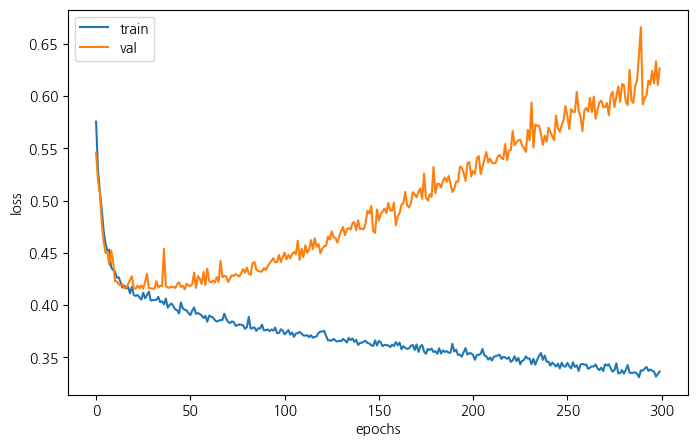

In [42]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# 모델 예측값 출력

In [43]:
pred = model.predict(X_test_ppd)
pred

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


array([[0.5176253 ],
       [0.541066  ],
       [0.5160756 ],
       [0.53925663],
       [0.5316245 ],
       [0.52056026],
       [0.5285286 ],
       [0.50303435],
       [0.53854364],
       [0.50283366],
       [0.5171147 ],
       [0.5159374 ],
       [0.5191371 ],
       [0.5172511 ],
       [0.53475404],
       [0.49816573],
       [0.5160756 ],
       [0.51450896],
       [0.50125355],
       [0.52726424],
       [0.53822803],
       [0.5148732 ],
       [0.52045363],
       [0.53925663],
       [0.53150344],
       [0.51682705],
       [0.4997318 ],
       [0.51694167],
       [0.54240495],
       [0.5127966 ],
       [0.50049585],
       [0.49962357],
       [0.5160756 ],
       [0.49627537],
       [0.5152275 ],
       [0.5235011 ],
       [0.5160756 ],
       [0.52259845],
       [0.5160756 ],
       [0.5237322 ],
       [0.5285286 ],
       [0.5301313 ],
       [0.54341257],
       [0.514246  ],
       [0.5126577 ],
       [0.5168366 ],
       [0.51690555],
       [0.530

In [44]:
result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result['pred'] =  result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
result

,y_test,pred
625,0,1
566,0,1
459,0,1
804,1,1
338,1,1
...,...,...
184,1,1
607,1,1
624,0,1
103,0,1


In [35]:
from keras.layers import Input, Dense
from keras.models import Model

# class형으로 만들기 (Model Subclass API)
* class 형태의 모델 정의 방법
* keras의 Model을 상속받아 작성

In [39]:
class Titanic(Model):
    def __init__(self):
        super().__init__() # 입력층
        self.dense1 = Dense(128, activation='relu') # 은닉층
        self.dense2 = Dense(64, activation='relu')  # 은닉층
        self.dense3 = Dense(32, activation='relu')  # 은닉층
        self.dense4 = Dense(16, activation='relu')  # 은닉층
        self.outputs = Dense(1, activation='sigmoid') # 출력층
        
    def call(self, inputs): # 실제 모델
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        return self.outputs(x)
        
        

In [40]:
model = Titanic()
print(model.summary())

Model: "titanic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
history = model.fit(X_train_ppd, y_train, epochs=300, batch_size=16,
                   validation_data=(X_test_ppd, y_test))